#  Laboratorio de Pandas Avanzado: Limpieza y Transformación Compleja

##  Contexto: Logística y Movilidad Urbana

1. **Fase 1 — Ingeniería de Datos Temporales**: estandarización de fechas, indexación, resampling y zonas horarias.
2. **Fase 2 — Transformación Geoespacial**: de `DataFrame` a `GeoDataFrame`, geometría `Point`, CRS y proyecciones.
3. **Fase 3 — Intersección y Visualización**: `spatial join` con distritos administrativos, tendencia temporal y mapa de intensidad.


## 0. Librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

print("pandas:", pd.__version__)
print("geopandas:", gpd.__version__)


pandas: 2.3.3
geopandas: 1.0.1


## 1. Dataset sintético de servicios de movilidad

Generamos ~600 servicios (moto-taxi, delivery, transporte de pasajeros) con `timestamp`, `latitud`/`longitud` y duración del servicio.

**A propósito metemos algunos timestamps corruptos** (texto inválido) para poder practicar `errors='coerce'` con un caso real y no solo en teoría.


In [6]:
rng = np.random.default_rng(42)
N = 600

# Ventana temporal del dataset (3 meses)
fechas_validas = pd.date_range("2026-01-01", "2026-03-31 23:00:00", freq="h")
timestamps_raw = rng.choice(fechas_validas.astype(str), size=N).tolist()

# Timestamps corruptos a propósito (~2.5%)
idx_corruptos = rng.choice(N, size=15, replace=False)
for i in idx_corruptos:
    timestamps_raw[i] = rng.choice(["fecha_invalida", "31/13/2026", "", "N/A"])

# Bounding box aproximado del area metropolitana de San Salvador (AMSS)
LAT_MIN, LAT_MAX = 13.63, 13.75
LON_MIN, LON_MAX = -89.30, -89.15

df = pd.DataFrame({
    "servicio_id": np.arange(1, N + 1),
    "timestamp": timestamps_raw,
    "latitud": rng.uniform(LAT_MIN - 0.02, LAT_MAX + 0.02, N), 
    "longitud": rng.uniform(LON_MIN - 0.02, LON_MAX + 0.02, N),
    "tipo_servicio": rng.choice(
        ["moto_taxi", "delivery", "transporte_pasajeros"], size=N, p=[0.3, 0.4, 0.3]
    ),
    "duracion_min": rng.gamma(shape=2.0, scale=8.0, size=N).round(1),
})

print(f"Filas generadas: {len(df)}")
df.head()


Filas generadas: 600


,servicio_id,timestamp,latitud,longitud,tipo_servicio,duracion_min
0,1,2026-01-09 00:00:00,13.662538,-89.202816,transporte_pasajeros,8.2
1,2,2026-03-11 15:00:00,13.695670,-89.216951,transporte_pasajeros,13.0
2,3,2026-02-28 21:00:00,13.745770,-89.288591,transporte_pasajeros,1.2
3,4,2026-02-09 11:00:00,13.714414,-89.271881,moto_taxi,18.0
4,5,2026-02-08 23:00:00,13.738703,-89.289541,delivery,4.6


##  Fase 1: Ingeniería de Datos Temporales

### Estandarización e indexación

Convertimos `timestamp` con `pd.to_datetime(..., errors='coerce')`: lo que no se puede parsear se vuelve `NaT` en vez de romper el pipeline entero.


In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"].apply(str), errors="coerce")

n_invalidos = df["timestamp"].isna().sum()
print(f"Timestamps inválidos (NaT) encontrados: {n_invalidos} de {len(df)}")

# Sin timestamp válido no hay forma de ubicar el registro en el tiempo, se descarta
df = df.dropna(subset=["timestamp"]).copy()
print(f"Filas después de limpiar: {len(df)}")


Timestamps inválidos (NaT) encontrados: 15 de 600
Filas después de limpiar: 585


In [ ]:
# El tiempo como índice habilita todas las operaciones de series temporales (resample, slicing por fecha, etc.)
df = df.set_index("timestamp").sort_index()

# Variables temporales derivadas
df["anio"] = df.index.year
df["mes"] = df.index.month
df["dia_semana"] = df.index.day_name()
df["hora"] = df.index.hour
df["es_fin_de_semana"] = df.index.dayofweek >= 5

df.head()


,servicio_id,latitud,longitud,tipo_servicio,duracion_min,anio,mes,dia_semana,hora,es_fin_de_semana
timestamp,,,,,,,,,,
2026-01-01 11:00:00,381,13.634871,-89.176447,transporte_pasajeros,22.4,2026,1,Thursday,11,False
2026-01-01 14:00:00,465,13.740105,-89.185899,moto_taxi,10.0,2026,1,Thursday,14,False
2026-01-01 15:00:00,104,13.738237,-89.262529,transporte_pasajeros,26.1,2026,1,Thursday,15,False
2026-01-01 21:00:00,303,13.766467,-89.287328,transporte_pasajeros,11.0,2026,1,Thursday,21,False
2026-01-02 06:00:00,410,13.618154,-89.225648,delivery,3.4,2026,1,Friday,6,False


###  Poder de Pandas: Resampling

Con el tiempo como índice, `resample()` agrega los servicios por ventanas de tiempo regulares (`'W'` semanal, `'ME'` fin de mes) sin necesidad de un `groupby` manual. Aprovechamos para sacar más de una métrica a la vez con `.agg(...)`.


In [ ]:
resample_semanal = df.resample("W").agg(
    total_servicios=("servicio_id", "count"),
    duracion_promedio=("duracion_min", "mean"),
)

resample_mensual = df.resample("ME").agg(   # 'ME' = fin de mes
    total_servicios=("servicio_id", "count"),
    duracion_promedio=("duracion_min", "mean"),
)

print("Servicios por semana (primeras filas):")
from IPython.display import display
display(resample_semanal.head())

print("\nServicios por mes:")
display(resample_mensual)


Servicios por semana (primeras filas):


,total_servicios,duracion_promedio
timestamp,,
2026-01-04,23,22.456522
2026-01-11,49,15.363265
2026-01-18,54,19.211111
2026-01-25,36,17.255556
2026-02-01,49,14.653061



Servicios por mes:


,total_servicios,duracion_promedio
timestamp,,
2026-01-31,208,17.075481
2026-02-28,168,16.501190
2026-03-31,209,16.398086


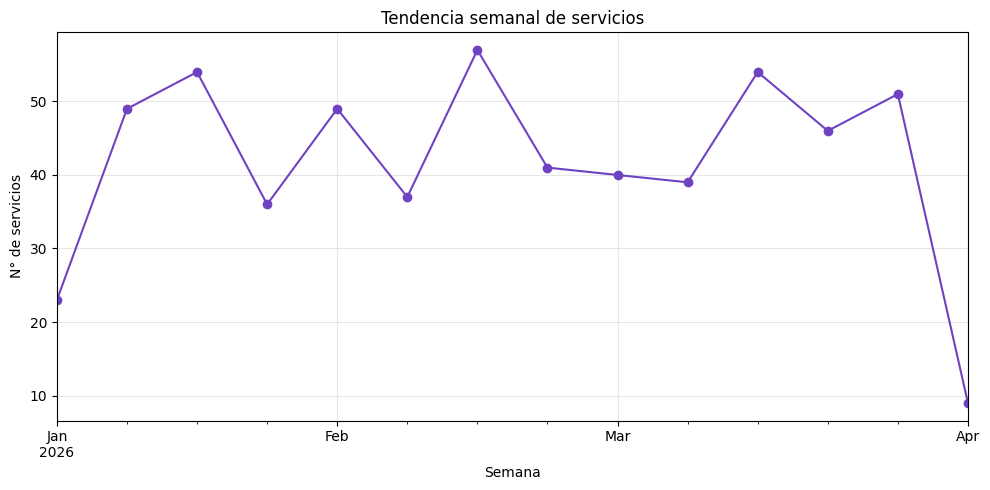

In [10]:
fig, ax = plt.subplots()
resample_semanal["total_servicios"].plot(ax=ax, marker="o", color="#6f42c1")
ax.set_title("Tendencia semanal de servicios")
ax.set_xlabel("Semana")
ax.set_ylabel("N° de servicios")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Zonas horarias (`tz_localize` / `tz_convert`)

Los timestamps generados están "naive" (sin zona horaria). Los localizamos en la zona horaria de El Salvador y de ahí los convertimos a UTC, útil cuando hay que cruzar esto con datos de otro sistema.

Usamos `nonexistent="shift_forward"` y `ambiguous="NaT"` para que la localización no truene si algún timestamp cae justo en un cambio de horario (borde poco común pero puede pasar).


In [11]:
df_tz = df.copy()
df_tz.index = df_tz.index.tz_localize(
    "America/El_Salvador", nonexistent="shift_forward", ambiguous="NaT"
)

print("Hora local (El Salvador):")
print(df_tz.index[:3])

df_tz_utc = df_tz.tz_convert("UTC")
print("\nConvertido a UTC:")
print(df_tz_utc.index[:3])


Hora local (El Salvador):
DatetimeIndex(['2026-01-01 11:00:00-06:00', '2026-01-01 14:00:00-06:00',
               '2026-01-01 15:00:00-06:00'],
              dtype='datetime64[ns, America/El_Salvador]', name='timestamp', freq=None)

Convertido a UTC:
DatetimeIndex(['2026-01-01 17:00:00+00:00', '2026-01-01 20:00:00+00:00',
               '2026-01-01 21:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', freq=None)


##  Fase 2: Transformación Geoespacial

### Del DataFrame al GeoDataFrame

- **Geometría**: creamos objetos `Point` (Shapely) a partir de `longitud` y `latitud` (¡en ese orden! Shapely usa `Point(x, y)` = `Point(lon, lat)`).
- **CRS**: asignamos el sistema de referencia **WGS84 (EPSG:4326)**, el estándar de coordenadas GPS lat/lon.


In [12]:
df_geo = df.reset_index()  # recuperamos 'timestamp' como columna normal

geometry = [Point(xy) for xy in zip(df_geo["longitud"], df_geo["latitud"])]
gdf = gpd.GeoDataFrame(df_geo, geometry=geometry, crs="EPSG:4326")

print(gdf.crs)
gdf.head()


EPSG:4326


,timestamp,servicio_id,latitud,longitud,tipo_servicio,duracion_min,anio,mes,dia_semana,hora,es_fin_de_semana,geometry
0,2026-01-01 11:00:00,381,13.634871,-89.176447,transporte_pasajeros,22.4,2026,1,Thursday,11,False,POINT (-89.17645 13.63487)
1,2026-01-01 14:00:00,465,13.740105,-89.185899,moto_taxi,10.0,2026,1,Thursday,14,False,POINT (-89.1859 13.74011)
2,2026-01-01 15:00:00,104,13.738237,-89.262529,transporte_pasajeros,26.1,2026,1,Thursday,15,False,POINT (-89.26253 13.73824)
3,2026-01-01 21:00:00,303,13.766467,-89.287328,transporte_pasajeros,11.0,2026,1,Thursday,21,False,POINT (-89.28733 13.76647)
4,2026-01-02 06:00:00,410,13.618154,-89.225648,delivery,3.4,2026,1,Friday,6,False,POINT (-89.22565 13.61815)


> ⚠ **Nota crítica:** EPSG:4326 trabaja en grados, no en metros. Si necesitas calcular **distancias reales** (p. ej. entre dos servicios), primero debes **proyectar a un CRS local**.
>
> Para San Salvador / El Salvador, el CRS proyectado correcto es **UTM zona 16N (EPSG:32616)**.


In [ ]:
gdf_metros = gdf.to_crs(epsg=32616)

# Ejemplo: distancia real entre los dos primeros servicios
d = gdf_metros.geometry.iloc[0].distance(gdf_metros.geometry.iloc[1])
print(f"CRS proyectado: {gdf_metros.crs}")
print(f"Distancia entre el servicio 1 y 2: {d:,.1f} metros")


CRS proyectado: EPSG:32616
Distancia entre el servicio 1 y 2: 11,691.0 metros


##  Fase 3: Intersección y Visualización

### Unión espacial (Spatial Join)

Para no depender de ningún archivo, generamos los distritos administrativos como una cuadrícula 3x3 con nombres de municipios del Área Metropolitana de San Salvador, usando `shapely.box` para armar los polígonos de forma directa.


In [ ]:
nombres_distritos = [
    "San Salvador Centro", "San Salvador Norte", "San Salvador Sur",
    "Mejicanos", "Ayutuxtepeque", "Soyapango",
    "Antiguo Cuscatlán", "Santa Tecla", "Ilopango",
]

lat_edges = np.linspace(LAT_MIN, LAT_MAX, 4)
lon_edges = np.linspace(LON_MIN, LON_MAX, 4)

poligonos = []
for i in range(3):       # filas (latitud)
    for j in range(3):    # columnas (longitud)
        poligonos.append(box(lon_edges[j], lat_edges[i], lon_edges[j + 1], lat_edges[i + 1]))

distritos = gpd.GeoDataFrame(
    {"distrito": nombres_distritos},
    geometry=poligonos,
    crs="EPSG:4326",   #debe coincidir con el CRS de gdf para que el sjoin funcione
)

distritos.head()


,distrito,geometry
0,San Salvador Centro,"POLYGON ((-89.25 13.63, -89.25 13.67, -89.3 13..."
1,San Salvador Norte,"POLYGON ((-89.2 13.63, -89.2 13.67, -89.25 13...."
2,San Salvador Sur,"POLYGON ((-89.15 13.63, -89.15 13.67, -89.2 13..."
3,Mejicanos,"POLYGON ((-89.25 13.67, -89.25 13.71, -89.3 13..."
4,Ayutuxtepeque,"POLYGON ((-89.2 13.67, -89.2 13.71, -89.25 13...."


In [ ]:
# a cada servicio le pegamos el distrito donde cae
gdf_zonas = gpd.sjoin(gdf, distritos, how="left", predicate="within")

n_fuera = gdf_zonas["distrito"].isna().sum()
print(f"Servicios fuera de todos los distritos (fuera del bbox): {n_fuera}")

gdf_zonas[["servicio_id", "timestamp", "tipo_servicio", "distrito"]].head()


Servicios fuera de todos los distritos (fuera del bbox): 247


,servicio_id,timestamp,tipo_servicio,distrito
0,381,2026-01-01 11:00:00,transporte_pasajeros,San Salvador Sur
1,465,2026-01-01 14:00:00,moto_taxi,Ilopango
2,104,2026-01-01 15:00:00,transporte_pasajeros,Antiguo Cuscatlán
3,303,2026-01-01 21:00:00,transporte_pasajeros,NaN
4,410,2026-01-02 06:00:00,delivery,NaN


In [16]:
conteo_por_zona = (
    gdf_zonas.dropna(subset=["distrito"])
    .groupby("distrito", observed=True)
    .size()
    .rename("total_servicios")
)

mapa_calor = distritos.merge(conteo_por_zona, left_on="distrito", right_index=True, how="left")
mapa_calor["total_servicios"] = mapa_calor["total_servicios"].fillna(0)

mapa_calor[["distrito", "total_servicios"]].sort_values("total_servicios", ascending=False)


,distrito,total_servicios
4,Ayutuxtepeque,47
8,Ilopango,47
6,Antiguo Cuscatlán,44
7,Santa Tecla,40
3,Mejicanos,36
0,San Salvador Centro,33
1,San Salvador Norte,32
2,San Salvador Sur,32
5,Soyapango,27


### Visualización — Líneas: tendencia temporal de eventos

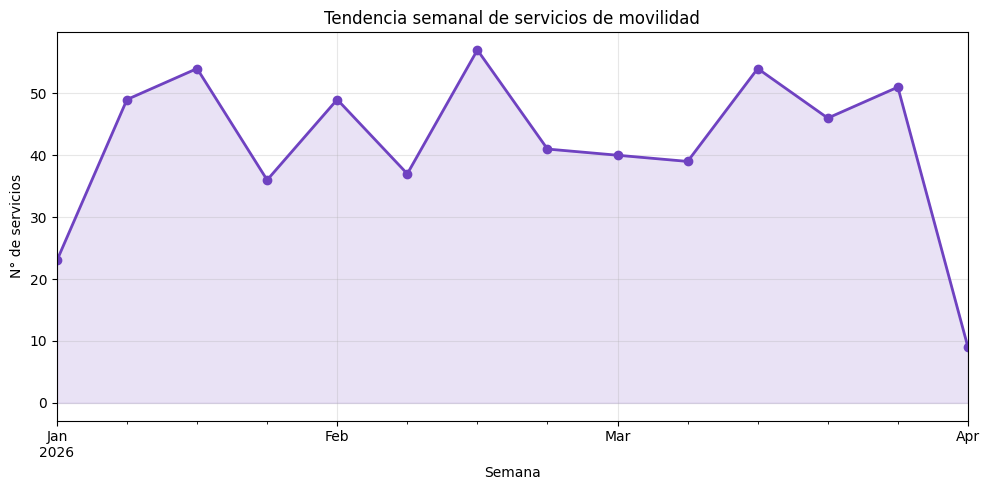

In [17]:
fig, ax = plt.subplots()
resample_semanal["total_servicios"].plot(ax=ax, color="#6f42c1", linewidth=2, marker="o")
ax.fill_between(resample_semanal.index, resample_semanal["total_servicios"], alpha=0.15, color="#6f42c1")
ax.set_title("Tendencia semanal de servicios de movilidad")
ax.set_xlabel("Semana")
ax.set_ylabel("N° de servicios")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Visualización — Mapa: intensidad por zonas administrativas

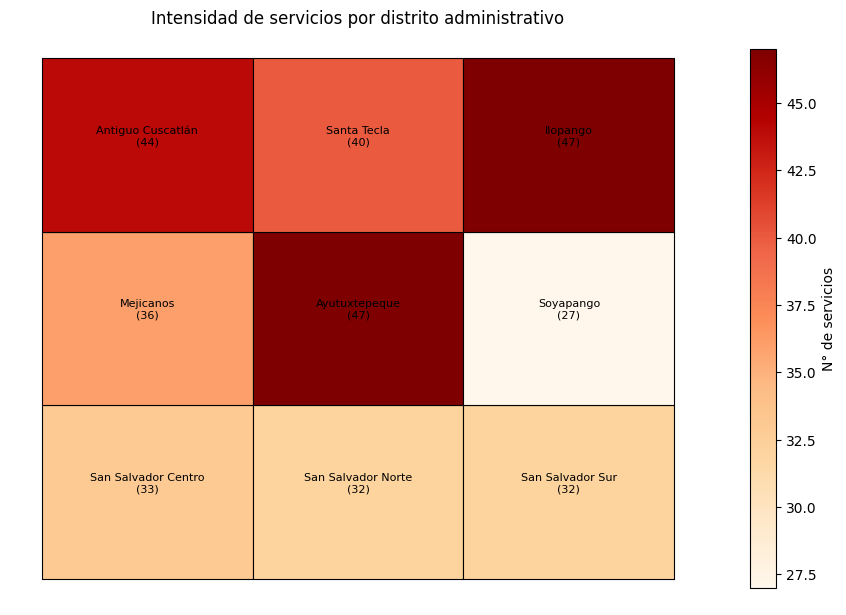

In [18]:
fig, ax = plt.subplots(figsize=(9, 8))

mapa_calor.plot(
    column="total_servicios",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "N° de servicios", "shrink": 0.7},
    ax=ax,
)

for _, row in mapa_calor.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        f"{row['distrito']}\n({int(row['total_servicios'])})",
        xy=(centroide.x, centroide.y),
        ha="center", fontsize=8, color="black",
    )

ax.set_title("Intensidad de servicios por distrito administrativo")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Conclusión

- **Fase 1**: se estandarizaron los timestamps con `errors='coerce'` (detectando y descartando los inválidos), se estableció el tiempo como índice, se agregaron los servicios por semana y mes con `resample`, y se manejaron zonas horarias con `tz_localize`/`tz_convert`.
- **Fase 2**: se transformaron las coordenadas en geometría `Point` con CRS **EPSG:4326** (WGS84), y se proyectaron a **EPSG:32616** (UTM 16N) para poder calcular distancias reales en metros.
- **Fase 3**: se cruzaron los servicios con los distritos administrativos mediante `sjoin`, y se generaron las dos visualizaciones pedidas: la tendencia temporal (línea) y el mapa de intensidad por zona.

